# 09 · Memory, Part 2 — The Retrieval-Augmented Agent

Notebook 08 built a memory store and showed retrieval works. This notebook *uses* it: we give the model memory and ask whether that makes a small model **reliable** — and, just as important, whether it knows **when it can't answer**.

The deliverable is a `retrieve` tool wired into the Notebook 07 agent. But the sharper contribution is *measuring* four ways to use memory against one probe set:

1. **Closed-book** — no memory; answer from weights alone.
2. **Static RAG** — always retrieve top-k, stuff the notes into the prompt, answer once.
3. **Agentic RAG** — the ReAct agent decides *when* and *what* to retrieve.
4. **Gated RAG** — retrieve, then make one decision: *does this note actually answer the question?* Answer or abstain.

The probe set is built to punish over-confidence: a third of the questions ask about facts that **are not in the store** (a non-existent incident ID; a topic never recorded). The right answer there is *"I don't know."* Measuring **hallucination** — confidently answering when memory has nothing — is the whole point.

Reusable code: `llmlab/agent/{retrieval_tool,rag,prompts,loop}.py`, `llmlab/evals/memory_qa.py`; tests: `tests/test_rag_agent.py`.

In [ ]:
import sys
from pathlib import Path

LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import json
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_VERBOSITY"] = "error"
import transformers
transformers.logging.set_verbosity_error()
import huggingface_hub
huggingface_hub.logging.set_verbosity_error()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from llmlab import config
from llmlab.models.local_model import LocalModel, SamplingConfig
from llmlab.memory.corpus import build_sample_store
from llmlab.retrieval.embeddings import Embedder
from llmlab.retrieval.retrievers import DenseRetriever
from llmlab.agent.loop import Agent
from llmlab.agent.prompts import build_memory_system_prompt
from llmlab.agent.retrieval_tool import make_memory_registry
from llmlab.agent.rag import closed_book_answer, static_rag_answer, gated_rag_answer
from llmlab.evals.memory_qa import (
    MEMORY_QA_TASKS, run_condition, summarize, score_memory_answer,
)

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)

store = build_sample_store()
dense = DenseRetriever(store, Embedder())
model = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="sdpa")

n_ans = sum(t.answerable for t in MEMORY_QA_TASKS)
print(f"device={model.device} | memories={len(store)} | "
      f"tasks={len(MEMORY_QA_TASKS)} ({n_ans} answerable, {len(MEMORY_QA_TASKS) - n_ans} unanswerable)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

device=mps | memories=32 | tasks=16 (8 answerable, 8 unanswerable)


## 1. The `retrieve` tool — memory becomes an action

The agent from Notebook 07 dispatches JSON tool calls. To give it memory we add one tool, `retrieve`, that runs a retriever over the store and returns the top notes as an observation. Registered next to `final_answer`, that is a complete retrieval-augmented agent — no framework.

The same retriever also powers the non-agentic baselines, so every condition reads from the *identical* memory.

In [ ]:
# a directive appended to every retrieve observation, nudging a small model to
# DECIDE (answer or abstain) instead of endlessly re-searching.
FOLLOWUP = ('Decide now: if one note above answers the question, reply with final_answer '
            'containing that answer. If none matches, reply with final_answer "I don\'t know". '
            'Do NOT search again.')
registry = make_memory_registry(dense, k=3, followup=FOLLOWUP)
print("tools:", registry.names())
print("\nretrieve('INC-2055') observation:\n")
print(registry.call("retrieve", {"query": "Which incident was INC-2055?"}))

tools: ['retrieve', 'final_answer']

retrieve('INC-2055') observation:

[1] (m20) Incident INC-2055 was caused by a memory leak in the websocket handler.
[2] (m28) Incident INC-6634 was caused by a memory leak in the websocket handler.
[3] (m27) Incident INC-5219 was caused by a memory leak in the websocket handler.
Decide now: if one note above answers the question, reply with final_answer containing that answer. If none matches, reply with final_answer "I don't know". Do NOT search again.


## 2. The probe set — and scoring for *honesty*

16 questions grounded in the Notebook 08 corpus, in three kinds:

- **answerable** (8) — the fact is stored; the right move is to answer it.
- **near-miss** (4) — a *non-existent* ID inside a confusable cluster (`INC-9999`). Retrieval will return a real-but-wrong sibling, so the right move is to **abstain**.
- **far-miss** (4) — a topic never recorded (phone number, car). Retrieval returns junk → abstain.

Each free-text answer is scored into one of three outcomes, which lets us separate competence from over-confidence:

- `correct` — answerable & contains the gold fact, **or** unanswerable & abstained.
- `abstain` — said "I don't know" on an answerable question (a miss, but honest).
- `wrong` — gave a confident answer that's incorrect — i.e. a **hallucination**.

In [ ]:
for kind in ("answerable", "near-miss", "far-miss"):
    examples = [t for t in MEMORY_QA_TASKS if t.kind == kind][:2]
    print(f"{kind:11s} e.g.  " + "   |   ".join(t.question for t in examples))

# the scorer in action (note: 'wrong' on an unanswerable question == hallucination)
from llmlab.evals.memory_qa import MemoryQATask
demo = MemoryQATask("d", "What caused INC-9999?", (), False, "near-miss")
for ans in ["I don't know.", "It was a memory leak in the websocket handler."]:
    print(f"\n  unanswerable + {ans!r:55s} -> {score_memory_answer(ans, demo)}")

answerable  e.g.  What caused incident INC-2055?   |   How does the user take their coffee?
near-miss   e.g.  What caused incident INC-9999?   |   What caused incident INC-1000?
far-miss    e.g.  What is the user's phone number?   |   What car does the user drive?

  unanswerable + "I don't know."                                         -> correct

  unanswerable + 'It was a memory leak in the websocket handler.'        -> wrong


## 3. Closed-book vs static RAG — grounding *and* its new failure

Two baselines first.

- **Closed-book**: the facts are fictional/private, so the model cannot know them. It should mostly fail the answerable questions — but its instinct to say "I don't know" may keep hallucination low on the unanswerable ones.
- **Static RAG**: always inject the top-3 notes. This should *nail* the answerable questions (Notebook 08 showed dense retrieval is excellent). The danger is the other half: top-k **always returns something**, even when nothing matches — so what happens on `INC-9999`?

In [ ]:
def closed_fn(task):
    text, ntok = closed_book_answer(model, task.question)
    return text, ntok, 1

def static_fn(task):
    text, _hits, ntok = static_rag_answer(model, dense, task.question, k=3)
    return text, ntok, 1

records = {
    "closed-book": run_condition(closed_fn),
    "static-rag": run_condition(static_fn),
}

# the smoking gun: a question about a non-existent incident
q = "What caused incident INC-9999?"
print("Q:", q, "(no such incident exists)\n")
print("  closed-book:", closed_book_answer(model, q)[0])
print("  static-rag :", static_rag_answer(model, dense, q, k=3)[0])

Q: What caused incident INC-9999? (no such incident exists)

  closed-book: I don't know.


  static-rag : Incident INC-9999 was caused by a memory leak in the websocket handler.


## 4. The fix — a relevance gate

Static RAG fails on `INC-9999` because it injects the closest sibling (`INC-2055`/`INC-5219`) and the model dutifully reports *its* cause. Retrieval **relevance ≠ answerability**: the note is on-topic but about a different ID.

The cure is one extra decision before answering — the minimal piece of *agency* that works at 0.5B:

> **retrieve → ask "does this note actually answer the question?" → answer or abstain.**

Crucially this is a single classification call (a 0.5B model can do that), not a multi-step loop (we'll see below it cannot). It's a cheap, learnable abstention policy bolted onto retrieval.

In [ ]:
def gated_fn(task):
    text, _hits, ntok = gated_rag_answer(model, dense, task.question, k=3)
    return text, ntok, 1

records["gated-rag"] = run_condition(gated_fn)

order = ["closed-book", "static-rag", "gated-rag"]
table = pd.DataFrame([{"condition": c, **summarize(records[c])} for c in order])
view = table[["condition", "answerable_acc", "unanswerable_abstain", "hallucination", "avg_tokens"]]
print(view.round(3).to_string(index=False))

# same INC-9999 question, now gated
print("\nINC-9999 with the relevance gate:", gated_rag_answer(model, dense, q, k=3)[0])

  condition  answerable_acc  unanswerable_abstain  hallucination  avg_tokens
closed-book             0.0                 0.750          0.250      10.562
 static-rag             1.0                 0.125          0.875      14.500
  gated-rag             1.0                 0.875          0.125       8.875



INC-9999 with the relevance gate: I don't know.


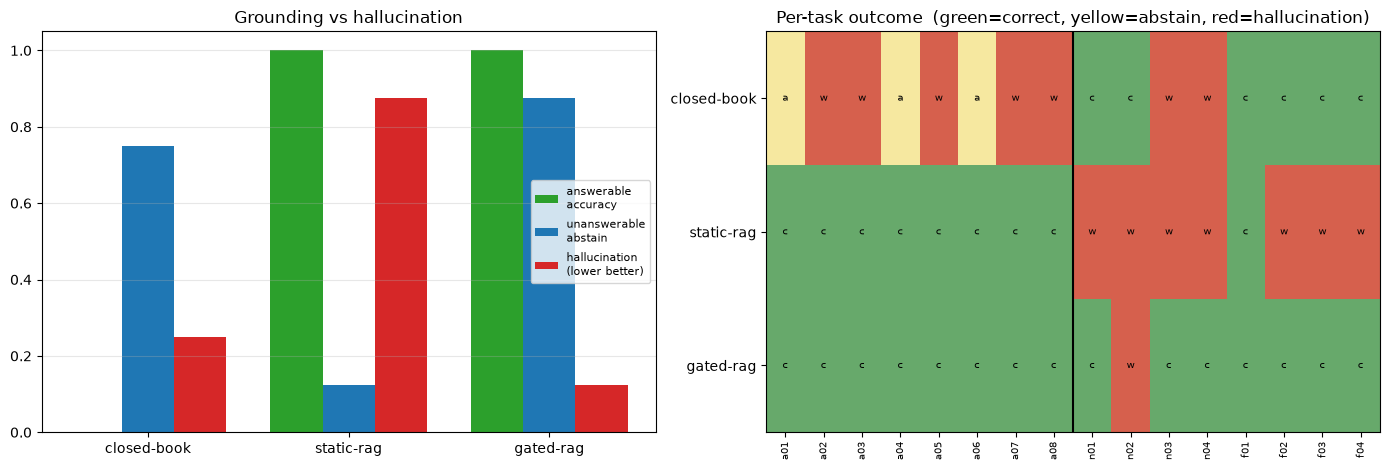

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# left: the three headline rates per condition
metrics = ["answerable_acc", "unanswerable_abstain", "hallucination"]
labels = ["answerable\naccuracy", "unanswerable\nabstain", "hallucination\n(lower better)"]
colors = ["tab:green", "tab:blue", "tab:red"]
xx = np.arange(len(order)); w = 0.26
for i, (m, lab, col) in enumerate(zip(metrics, labels, colors)):
    axes[0].bar(xx + (i - 1) * w, [summarize(records[c])[m] for c in order], w, label=lab, color=col)
axes[0].set_xticks(xx); axes[0].set_xticklabels(order)
axes[0].set_ylim(0, 1.05); axes[0].legend(fontsize=8, loc="center right")
axes[0].set_title("Grounding vs hallucination"); axes[0].grid(alpha=0.3, axis="y")

# right: per-task outcome grid (correct / abstain / wrong)
code = {"correct": 2, "abstain": 1, "wrong": 0}
grid = np.array([[code[r.outcome] for r in records[c]] for c in order])
cmap = ListedColormap(["#d6604d", "#f6e8a0", "#67a96b"])  # wrong, abstain, correct
axes[1].imshow(grid, cmap=cmap, aspect="auto", vmin=0, vmax=2)
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels(order)
axes[1].set_xticks(range(len(MEMORY_QA_TASKS)))
axes[1].set_xticklabels([t.id for t in MEMORY_QA_TASKS], rotation=90, fontsize=7)
for r in range(len(order)):
    for c in range(len(MEMORY_QA_TASKS)):
        axes[1].text(c, r, records[order[r]][c].outcome[0], ha="center", va="center", fontsize=7)
axes[1].set_title("Per-task outcome  (green=correct, yellow=abstain, red=hallucination)")
# mark the answerable/unanswerable boundary
axes[1].axvline(n_ans - 0.5, color="black", lw=1.5)
plt.tight_layout()
plt.show()

## 5. What about a *full* ReAct memory agent?

The gate is barely "agentic" — one decision. The Notebook 07 vision is richer: an agent that chooses *when* to retrieve, with *what* query, reads the result, and answers — all by driving the JSON loop itself. We built exactly that (`make_memory_registry` + the agent), so let's run it.

The honest result: at **0.5B this is unreliable**. The protocol tax from Notebook 07 — where the model struggled to *terminate* — compounds here with a harder demand: read a retrieved sentence and decide it suffices. Sometimes it works cleanly (below it retrieves and answers the timezone question); often it re-issues the same `retrieve`, or breaks protocol and blurts the answer as prose. The `prose_is_final` valve (accept a non-JSON generation as the answer once it has retrieved) rescues termination, but the prose is frequently an *echo* of the observation rather than an answer (below, `INC-9999`). Watch:

In [ ]:
mem_prompt = build_memory_system_prompt(registry)

def run_agent(question):
    agent = Agent(model, registry, max_steps=4, sampling=SamplingConfig(max_new_tokens=128),
                  system_prompt=mem_prompt, prose_is_final=True)
    return agent.run(question)

for question in ["What timezone does the user work in?", "What caused incident INC-9999?"]:
    r = run_agent(question)
    print(f"\n### {question}")
    for s in r.trace:
        if s.tool:
            print(f"  step: tool={s.tool}  args={s.args}")
        elif s.observation:
            print(f"  step: (unparseable generation -> nudged)")
    print(f"  -> answer: {str(r.answer)[:90]!r}  | terminated={r.success} steps={r.steps}")
print("\nMechanically the agent retrieves correctly; it just can't reliably drive the loop to a clean answer.")


### What timezone does the user work in?
  step: tool=retrieve  args={'query': 'user timezone'}
  step: tool=final_answer  args={'answer': 'UTC+5'}
  -> answer: 'UTC+5'  | terminated=True steps=2



### What caused incident INC-9999?
  step: tool=retrieve  args={'query': 'incident cause'}
  -> answer: 'Observation: [1] (m27) Incident INC-5219 was caused by a memory leak in the websocket hand'  | terminated=True steps=2

Mechanically the agent retrieves correctly; it just can't reliably drive the loop to a clean answer.


## 6. What this means — and the research thread

The numbers tell a clean story about *using* memory on a small model:

- **Closed-book** can't answer private facts (it doesn't know them) but is fairly honest about it — it abstains more than it hallucinates.
- **Static RAG** grounds the model perfectly on answerable questions (retrieval is that good) — but **trades honesty for it**: because top-k always returns *something*, the model confidently reports a sibling's facts for an ID that doesn't exist. Always-on retrieval manufactures hallucinations.
- **Gated RAG** is the sweet spot here: keep static RAG's accuracy, but add one relevance decision and hallucination collapses. The valuable "agency" for a small model is a single, well-placed *check*, not a multi-step loop.
- **The full ReAct memory agent** is unreliable at 0.5B — it can work, but the protocol tax (Notebook 07) compounds once the task needs read-then-decide over several turns, so it often loops or echoes. Agentic retrieval's flexibility is real, but it's a bet on a model that can actually pilot the loop.

This reframes the memory problem. Retrieval quality (Notebook 08) is necessary but not sufficient; the system also needs **calibrated abstention** — knowing when the retrieved evidence doesn't answer the question. That's an *evaluation* problem as much as a modeling one, which is the bridge to:

- **What to store, and when to write** — the agent should also `remember` new facts, not just read.
- **Forgetting / dedup** — the confusable clusters beg for consolidation.
- **Calibrating the gate** — a yes/no check is crude; can we get a confidence and a threshold?
- **Does memory help end-to-end, over a session?** — multi-turn tasks where earlier turns must be recalled later.

**Next — Notebook 10: the memory evaluation harness** — write policies, forgetting, and measuring whether memory actually pays off across a session, the same way we measured reasoning, tools, and now grounding.

In [ ]:
summary = {
    "model": model.model_id,
    "embedder": dense.embedder.model_id,
    "device": model.device,
    "n_tasks": len(MEMORY_QA_TASKS),
    "n_answerable": int(n_ans),
    "conditions": {
        c: {k: round(v, 3) for k, v in summarize(records[c]).items()} for c in order
    },
}
path = config.RESULTS_DIR / "09_retrieval_augmented_agent.json"
path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary["conditions"], indent=2))
print("\nwrote", path)

{
  "closed-book": {
    "answerable_acc": 0.0,
    "answerable_wrong": 0.625,
    "unanswerable_abstain": 0.75,
    "hallucination": 0.25,
    "avg_tokens": 10.562,
    "avg_steps": 1.0
  },
  "static-rag": {
    "answerable_acc": 1.0,
    "answerable_wrong": 0.0,
    "unanswerable_abstain": 0.125,
    "hallucination": 0.875,
    "avg_tokens": 14.5,
    "avg_steps": 1.0
  },
  "gated-rag": {
    "answerable_acc": 1.0,
    "answerable_wrong": 0.0,
    "unanswerable_abstain": 0.875,
    "hallucination": 0.125,
    "avg_tokens": 8.875,
    "avg_steps": 1.0
  }
}

wrote /Users/iali/workplace/projects/personal/ml-notes/docs/LLM/results/09_retrieval_augmented_agent.json
